# Pulling the Data from the Drive

In [6]:



from google.colab import drive
import zipfile
import os

# 1. חיבור ל-Google Drive
drive.mount('/content/drive')

# 2. הגדרת הנתיב לקובץ ה-ZIP בדרייב שלך
# על פי צילום המסך, הקובץ נמצא בתוך תיקיית 'content' ב-MyDrive
zip_path = '/content/drive/MyDrive/content/my_mini_fruits.zip'

# 3. הגדרת תיקיית היעד לחילוץ הקבצים
# נשתמש בנתיב שניסית להשתמש בו במקור
extract_path = '/content/dataset'

# יצירת התיקייה אם היא לא קיימת
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# 4. ביצוע החילוץ (Unzip)
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"הקבצים חולצו בהצלחה לתיקייה: {extract_path}")
except FileNotFoundError:
    print(f"שגיאה: קובץ ה-ZIP לא נמצא בנתיב {zip_path}. אנא בדוק את הנתיב.")
except Exception as e:
    print(f"אירעה שגיאה בעת החילוץ: {e}")

# 5. (אופציונלי) הדפסת מבנה התיקיות שנוצר כדי למצוא את הנתיב המדויק
print(f"\nתוכן התיקייה {extract_path}:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    # מדפיס רק את 5 הקבצים הראשונים בכל תיקייה כדי לא להעמיס
    for f in files[:5]:
        print(f"{subindent}{f}")
    if len(files) > 5:
        print(f"{subindent}... ({len(files)-5} קבצים נוספים)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
הקבצים חולצו בהצלחה לתיקייה: /content/dataset

תוכן התיקייה /content/dataset:
dataset/
    my_mini_fruits 2/
        .DS_Store
        Train/
            .DS_Store
            Strawberry/
                Strawberry_2nd204.jpg
                r_126_100.jpg
                193_100.jpg
                Strawberry_2nd54.jpg
                r_290_100.jpg
                ... (1181 קבצים נוספים)
            Apple /
                green_apple153.jpg
                green_apple129.jpg
                green_apple147.jpg
                r1_306_100.jpg
                r1_218_100.jpg
                ... (928 קבצים נוספים)
            Grape/
                Grape_2nd148.jpg
                Grape_2nd303.jpg
                r1_306_100.jpg
                r1_218_100.jpg
                r1_73_100.jpg
                ... (960 קבצים נוספים)
            Cucumber /
               

# If i Have a problem i run this to erase and start again

In [2]:
import shutil
shutil.rmtree('/content/dataset', ignore_errors=True)
print("התיקייה נמחקה, אפשר להתחיל מחדש נקי!")

התיקייה נמחקה, אפשר להתחיל מחדש נקי!


# Importing standard libraries


In [8]:
# Importing standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Optional: prevent TensorFlow from using GPU (for debugging or testing)
# tf.config.set_visible_devices([], 'GPU') # This line caused an error because devices were already initialized.
                                          # If you want to force CPU, run this line as the very first TensorFlow command.

# Check how many GPUs are available
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [9]:
import os

train_path = '/content/dataset/my_mini_fruits 2/Train'

# מעבר על כל התיקיות ב-Train והסרת רווחים בסוף השם
print("מתקן שמות תיקיות...")
for folder_name in os.listdir(train_path):
    old_dir = os.path.join(train_path, folder_name)
    if os.path.isdir(old_dir):
        new_folder_name = folder_name.strip() # פונקציה שמוחקת רווחים מהצדדים
        new_dir = os.path.join(train_path, new_folder_name)
        if old_dir != new_dir:
            os.rename(old_dir, new_dir)
            print(f"תוקן: מ-'{folder_name}' ל-'{new_folder_name}'")

print("סיימנו לתקן!")

מתקן שמות תיקיות...
תוקן: מ-'Apple ' ל-'Apple'
תוקן: מ-'Cucumber ' ל-'Cucumber'
תוקן: מ-'Banana ' ל-'Banana'
סיימנו לתקן!


In [10]:
import tensorflow as tf

# הגדרת נתיבי התיקיות החדשים
train_dir = '/content/dataset/my_mini_fruits 2/Train'
test_dir = '/content/dataset/my_mini_fruits 2/Test'
batch_size = 32
img_size = (100, 100)

print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size
)

print("\nLoading Test Data:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

Loading Training Data:
Found 4438 files belonging to 5 classes.

Loading Test Data:
Found 681 files belonging to 5 classes.


# Sanity Check

המחלקות שהמודל יזהה הן: ['Apple', 'Banana', 'Cucumber', 'Grape', 'Strawberry']


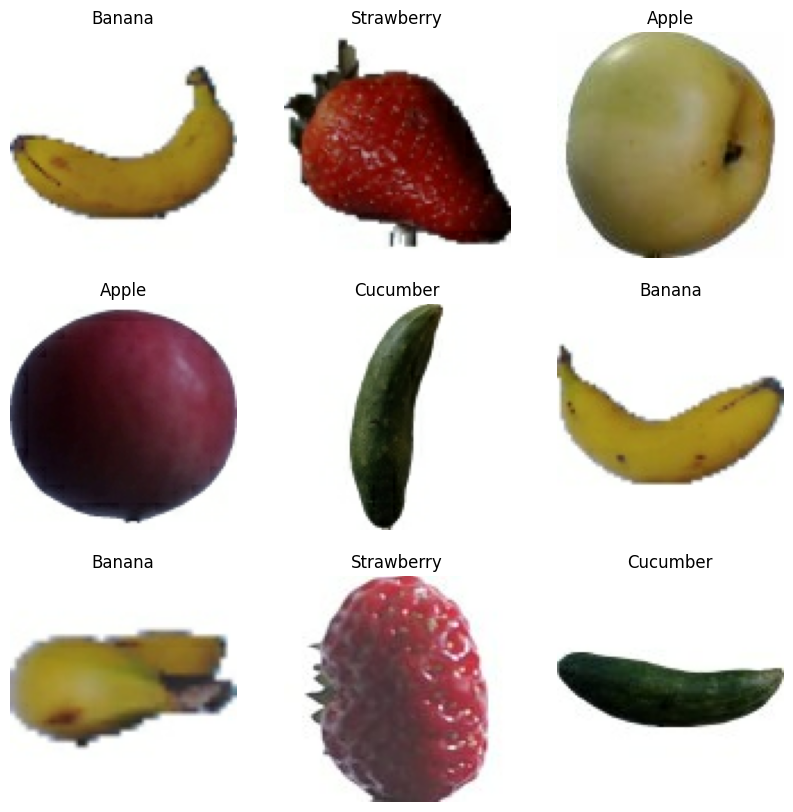

In [11]:
import matplotlib.pyplot as plt

# חילוץ שמות המחלקות (שמות תיקיות הפירות שלך)
class_names = train_dataset.class_names
print("המחלקות שהמודל יזהה הן:", class_names)

# יצירת חלון תצוגה
plt.figure(figsize=(10, 10))

# לקיחת "אצווה" (Batch) אחת של תמונות מהנתונים
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # המרת התמונה למערך והצגתה
        plt.imshow(images[i].numpy().astype("uint8"))
        # הדפסת שם הפרי מעל התמונה
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# בניית המודל המשודרג עם Data Augmentation ו-Dropout
cnn = models.Sequential([
    # --- שכבות העשרת נתונים (Data Augmentation) ---
    layers.RandomFlip("horizontal", input_shape=(100, 100, 3)), # הופך את התמונה ימינה-שמאלה
    layers.RandomRotation(0.1), # מסובב את התמונה מעט
    layers.RandomZoom(0.1), # עושה זום קל פנימה והחוצה

    # --- שכבות זיהוי הצורות (Convolution & Pooling) ---
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # --- שכבות ההחלטה (Dense & Dropout) ---
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # שכבת ה-Dropout שמונעת שינון (מכבה 50% מהנוירונים)
    layers.Dropout(0.5),

    # --- שכבת הפלט (5 סוגי פירות) ---
    layers.Dense(5, activation='softmax')
])

# הדפסת מבנה המודל החדש
cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 100, 100, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,421 (6.61 MB)

 Trainable params: 1,732,421 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# compiling
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("the model has compiled and ready to train!")

the model has compiled and ready to train!


In [14]:
# הגדרת מספר הפעמים שהמודל יעבור על כל נתוני האימון
# (10 פעמים זו נקודת התחלה טובה כדי לראות אם הוא לומד)
epochs = 10

print("Starting Training⏳")

# הפעלת האימון ושמירת ההיסטוריה שלו לתוך משתנה (כדי שנוכל לצייר גרפים אחר כך)
history = cnn.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs
)

print("\nTraining finished !! 🎉")

Starting Training⏳
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8481 - loss: 1.8688 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9766 - loss: 0.1061 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9687 - loss: 0.1146 - val_accuracy: 0.9310 - val_loss: 0.5593
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9838 - loss: 0.0756 - val_accuracy: 1.0000 - val_loss: 2.4697e-05
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9892 - loss: 0.0443 - val_accuracy: 1.0000 - val_loss: 9.9103e-05
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9892 - loss: 0.0438 - val_accuracy: 1.0000 - val_loss: 0.0073
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9707 - loss: 0.0952 - val_accuracy: 0.9383 - val_loss: 0.3489
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.80

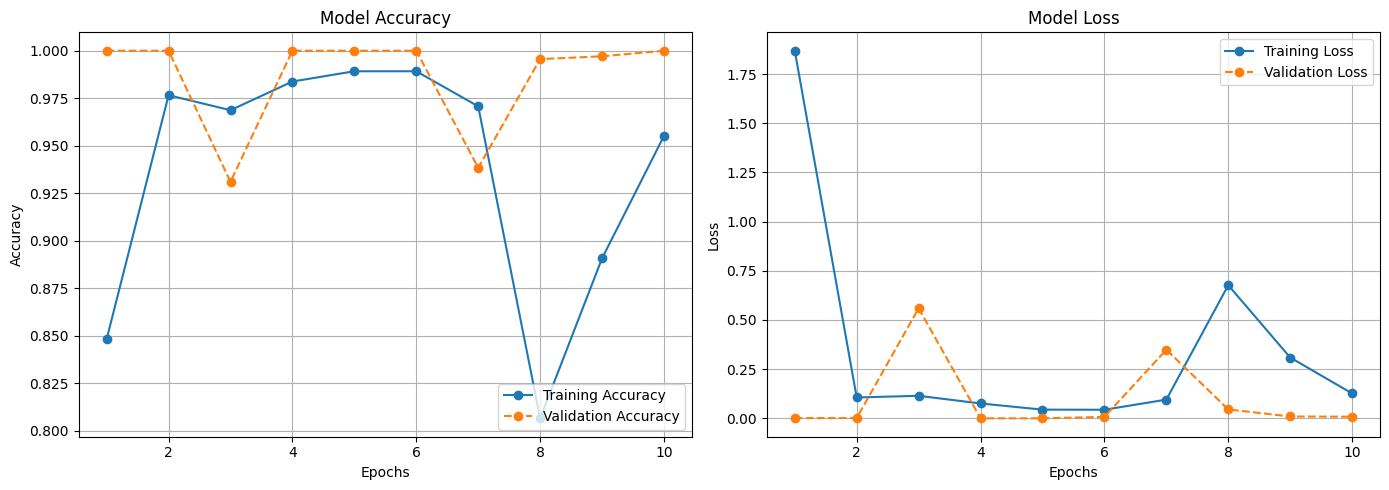

In [15]:
import matplotlib.pyplot as plt

# משיכת הנתונים מתוך ההיסטוריה של האימון
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# יצירת חלון התצוגה
plt.figure(figsize=(14, 5))

# יצירת גרף הדיוק (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', linestyle='--')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# יצירת גרף ההפסד (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', linestyle='--')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# הצגת הגרפים
plt.tight_layout()
plt.show()

אנא העלה תמונה של אחד מ-5 הפירות:


Saving Banana.jpeg to Banana.jpeg


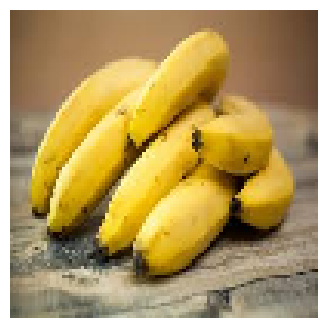

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

🍎🍌 התשובה של המודל:
אני חושב שזה: **Banana**
רמת ביטחון: 99.89%


In [18]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

print("אנא העלה תמונה של אחד מ-5 הפירות:")
# פתיחת חלונית העלאת קבצים ב-Colab
uploaded = files.upload()

for fn in uploaded.keys():
    # 1. טעינת התמונה והתאמת הגודל שלה למה שהמודל מכיר (100x100)
    path = '/content/' + fn
    img = image.load_img(path, target_size=(100, 100))

    # הצגת התמונה שהועלתה
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # 2. עיבוד התמונה למערך (Array) שהמודל יודע לקרוא
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) # הוספת מימד של "אצווה" (Batch)

    # 3. הפעלת המודל כדי לנחש מה יש בתמונה
    predictions = cnn.predict(x)

    # 4. מציאת הניחוש בעל ההסתברות הגבוהה ביותר
    predicted_class_index = np.argmax(predictions[0])

    # שליפת שם הפרי וההסתברות מתוך שמות המחלקות של נתוני האימון
    class_names = train_dataset.class_names
    predicted_fruit = class_names[predicted_class_index]
    confidence = np.max(predictions[0]) * 100

    print(f"\n🍎🍌 התשובה של המודל:")
    print(f"אני חושב שזה: **{predicted_fruit}**")
    print(f"רמת ביטחון: {confidence:.2f}%")

In [19]:
cnn.save('my_fruits_model.keras')
print("Model saved successfully as a file! You can now download it from the file explorer on the left.")

Model saved successfully as a file! You can now download it from the file explorer on the left.
